# AV2 (per-plot curve vs. yldc): Broader static attribution of growth-curve deviation

This is a separate extension of the terrain/wind-only analysis. It keeps the same cleaned `local_y_max_difference` target, five compartment-held-out spatial folds, 60 m leakage buffer, and Elastic Net/XGBoost models, but tests a wider range of predictors. The original terrain/wind notebook is not altered.

Three primary scopes are compared on exactly the same complete-case plots:

1. **Terrain/wind (17 raw variables):** the established baseline.
2. **Broad environment (33):** terrain/wind + climate + soil/site + forest-edge position.
3. **Broad environment + management (38):** the broad environmental set + canopy/thinning variables. Management is kept explicit because it is not an environmental effect.

> Scope note (2026-08-04): This notebook is the **AV2** extension that widens the static per-plot model beyond the validated terrain/wind set. It complements, rather than replaces, `av2_per_plot_growth_curve_story.ipynb`: use this one for broader category/group/all-variable comparisons and the management-vs-environment question.

In [1]:
import sys
from pathlib import Path

notebook_directory = Path.cwd().resolve()
project_root = next(folder for folder in [notebook_directory, *notebook_directory.parents] if (folder / 'README.md').exists())
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import pandas as pd

from models.growth_curve_attribution.broad_environmental_check import (
    FEATURE_GROUPS, SCOPE_GROUPS, columns_for_groups, run_comparison,
)

for group, columns in FEATURE_GROUPS.items():
    print(f'{group}: {len(columns)} raw variables')
    print('  ' + ', '.join(columns))

terrain_wind: 17 raw variables
  elevation, slope_degrees, northness, eastness, profile_curvature, plan_curvature, tpi, elevation_roughness, ceh_twi, solar_radiation_index, frost_hollow_flag, topex, windward_topex, whcl, gwa_wind_speed_50m, tpi_500m, local_relief_500m
climate: 5 raw variables
  tas_mean, groundfrost_mean, chelsa_bio1_celsius, chelsa_gdd5_degc, chelsa_bio12_precip_mm
soil_site: 5 raw variables
  soilgrids_ph, ceh_pedotope, ceh_subsurface_drainage, ceh_textural_composition, dist_to_watercourse
edge_position: 6 raw variables
  dist_to_cpmt_boundary, dist_to_forest_perimeter, dist_to_scpt_boundary, dist_to_block_boundary, cpmt_compactness_ratio, dist_to_road
management: 5 raw variables
  CanopyCover, Thin, time_since_thinning, time_since_thinning_missing, recent_thinning_5yr


## Design safeguards

HadUK temperature and ground-frost columns are resolved separately for each survey cohort. The unordered CEH pedotope, drainage, and texture class identifiers are one-hot encoded rather than treated as continuous numbers. Every model scope uses the complete cases from the largest requested scope, preventing missingness from changing the evaluation population between comparisons.

Leaked neighbour-height variables are excluded. Redundant wind formulae and the intermediate 250 m TPI are also excluded because earlier representation checks already selected 50 m mean wind and the native/500 m TPI extremes. Drought indices have not been extracted. MIDAS storm metrics are interval-level rather than static plot-level variables and therefore require a separate longitudinal design.

In [2]:
results = pd.concat([
    pd.read_csv(project_root / 'outputs/growth_curve_attribution/broad_environmental_spatial_cv_4survey.csv'),
    pd.read_csv(project_root / 'outputs/growth_curve_attribution/broad_environmental_spatial_cv_6survey.csv'),
], ignore_index=True)

display_columns = [
    'cohort', 'scope', 'method', 'n_raw_features', 'n_model_columns',
    'common_complete_case_n', 'pooled_r2', 'per_fold_r2_mean', 'per_fold_r2_std',
]
results[display_columns].round(3)

,cohort,scope,method,n_raw_features,n_model_columns,common_complete_case_n,pooled_r2,per_fold_r2_mean,per_fold_r2_std
0,4survey,terrain_wind,Elastic Net,17,17,56114,0.125,0.104,0.074
1,4survey,terrain_wind,XGBoost,17,17,56114,0.117,0.098,0.039
2,4survey,broad_environment,Elastic Net,33,44,56114,0.093,0.075,0.047
3,4survey,broad_environment,XGBoost,33,44,56114,0.102,0.086,0.035
4,4survey,broad_environment_plus_management,Elastic Net,38,49,56114,0.290,0.272,0.079
5,4survey,broad_environment_plus_management,XGBoost,38,49,56114,0.318,0.298,0.084
6,6survey,terrain_wind,Elastic Net,17,17,13335,0.023,-0.027,0.063
7,6survey,terrain_wind,XGBoost,17,17,13335,0.021,-0.028,0.037
8,6survey,broad_environment,Elastic Net,33,36,13335,0.019,-0.042,0.106
9,6survey,broad_environment,XGBoost,33,36,13335,0.027,-0.022,0.035


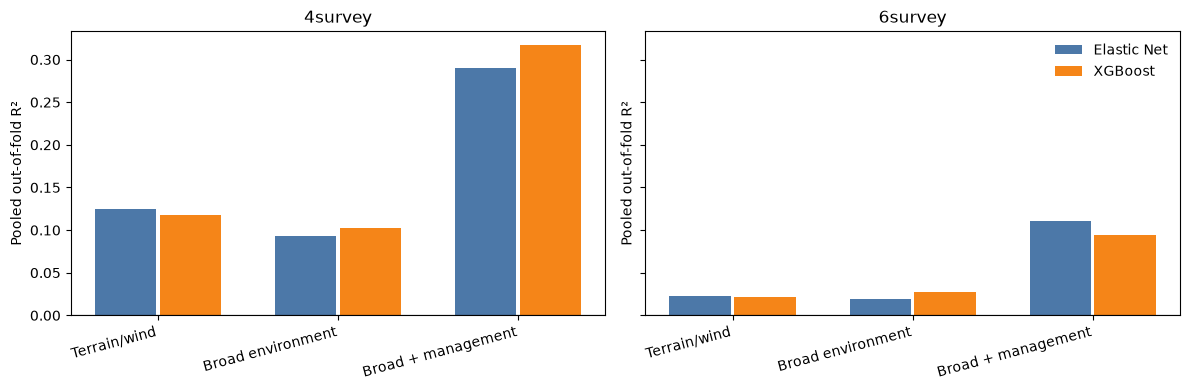

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
scope_order = ['terrain_wind', 'broad_environment', 'broad_environment_plus_management']
labels = ['Terrain/wind', 'Broad environment', 'Broad + management']
for ax, cohort in zip(axes, ['4survey', '6survey']):
    subset = results[results['cohort'].eq(cohort)]
    for method, offset, colour in [('Elastic Net', -0.18, '#4c78a8'), ('XGBoost', 0.18, '#f58518')]:
        values = subset[subset['method'].eq(method)].set_index('scope').loc[scope_order, 'pooled_r2']
        ax.bar([i + offset for i in range(3)], values, width=0.34, label=method, color=colour)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xticks(range(3), labels, rotation=15, ha='right')
    ax.set_title(cohort)
    ax.set_ylabel('Pooled out-of-fold R²')
axes[1].legend(frameon=False)
plt.tight_layout()
plt.show()

## Main finding

For **4survey**, adding climate, soil/site, and edge-position variables does not improve the established terrain/wind model: pooled R² changes from 0.125 to 0.093 for Elastic Net and from 0.117 to 0.102 for XGBoost. This means the broader environmental variables do not add useful out-of-compartment information as one combined bundle under this design; it does not prove that climate or soil have no biological effect. Coarse spatial resolution, collinearity with elevation, and limited within-forest variation can all suppress unique predictive value.

Adding canopy and thinning variables produces a much larger signal: R² = 0.290 (Elastic Net) and 0.318 (XGBoost). The same qualitative pattern appears in **6survey**, where broad environment remains near zero but environment + management reaches 0.110/0.094. This uplift must be reported as a stand-management result, not an environmental result.

## Compact control: terrain/wind + management only

Because climate, soil/site, and edge variables did not robustly improve performance, the key control is a 22-variable model containing the established 17 terrain/wind predictors plus the five canopy/thinning predictors. This tests whether management alone accounts for the larger 38-variable model's uplift.

In [4]:
management_comparison = pd.read_csv(
    project_root / 'outputs/growth_curve_attribution/terrain_wind_management_comparison.csv'
)
management_comparison[[
    'cohort', 'scope', 'method', 'n_raw_features', 'common_complete_case_n',
    'pooled_r2', 'per_fold_r2_mean', 'per_fold_r2_std',
]].round(3)

,cohort,scope,method,n_raw_features,common_complete_case_n,pooled_r2,per_fold_r2_mean,per_fold_r2_std
0,4survey,terrain_wind,Elastic Net,17,56114,0.125,0.104,0.074
1,4survey,terrain_wind,XGBoost,17,56114,0.117,0.098,0.039
2,4survey,terrain_wind_plus_management,Elastic Net,22,56114,0.289,0.268,0.114
3,4survey,terrain_wind_plus_management,XGBoost,22,56114,0.302,0.282,0.096
4,4survey,broad_environment_plus_management,Elastic Net,38,56114,0.290,0.272,0.079
5,4survey,broad_environment_plus_management,XGBoost,38,56114,0.318,0.298,0.084
6,6survey,terrain_wind,Elastic Net,17,13335,0.023,-0.027,0.063
7,6survey,terrain_wind,XGBoost,17,13335,0.021,-0.028,0.037
8,6survey,terrain_wind_plus_management,Elastic Net,22,13335,0.079,0.031,0.104
9,6survey,terrain_wind_plus_management,XGBoost,22,13335,0.101,0.054,0.041


### Compact-model finding

For 4survey, terrain/wind + management reaches R² = 0.289 (Elastic Net) and 0.302 (XGBoost), compared with 0.290/0.318 for all 38 variables. For 6survey it reaches 0.079/0.101, compared with 0.110/0.094 for all 38. Thus the compact 22-variable model captures nearly all of the larger model's signal and is the clearer primary management comparison. The result establishes the management group as useful; it does **not** yet establish that every management variable is individually important. Individual importance/stability or leave-one-variable-out checks are required before calling a smaller subset 'all significant variables'.

## Which broader environmental category changes performance?

The following comparison adds climate, soil/site, or edge-position variables separately to the same terrain/wind baseline. It helps distinguish a weak category from a combined-model overfitting effect.

In [5]:
category_path = project_root / 'outputs/growth_curve_attribution/broad_environmental_category_checks_4survey.csv'
category_results = pd.read_csv(category_path)
category_results[['scope', 'method', 'pooled_r2', 'per_fold_r2_mean', 'per_fold_r2_std']].round(3)

,scope,method,pooled_r2,per_fold_r2_mean,per_fold_r2_std
0,terrain_wind_plus_climate,Elastic Net,0.112,0.093,0.059
1,terrain_wind_plus_climate,XGBoost,0.127,0.107,0.045
2,terrain_wind_plus_soil_site,Elastic Net,0.117,0.098,0.053
3,terrain_wind_plus_soil_site,XGBoost,0.099,0.082,0.032
4,terrain_wind_plus_edge_position,Elastic Net,0.112,0.091,0.072
5,terrain_wind_plus_edge_position,XGBoost,0.121,0.101,0.063


### Category result

Against the common 4survey terrain/wind baseline (R² = 0.125 Elastic Net / 0.117 XGBoost), climate produces a small XGBoost increase to 0.127 but a linear-model decrease to 0.112. Edge position is effectively neutral (0.112/0.121), while soil/site reduces performance (0.117/0.099). These changes are small relative to fold-to-fold variation. Therefore no broader environmental category shows a robust, model-independent improvement; the large combined uplift comes specifically from the separately labelled management/stand variables.

## Reproduce the full comparison

The saved tables above are the completed run. Set the flag below only when a fresh, computationally expensive five-fold rerun is wanted.

In [6]:
RUN_FULL_CV = False
if RUN_FULL_CV:
    fresh_results = run_comparison()
    fresh_results[display_columns].round(3)